In [1]:
import torch

torch.cuda.is_available()

True

In [2]:
import sys
import os
import numpy

# Add OpenBLAS bin to the beginning of the PATH
os.environ["PATH"] = r"C:\TopoGAN-ECCV2020\OpenBLAS\bin;" + os.environ.get("PATH", "")

# # 1) register the folder that contains _persis_homo_optimal.pyd *and* any other DLLs it needs
# os.add_dll_directory(r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# 2) add the same folder to sys.path so Python can find the .pyd module by name
sys.path.insert(0, r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# python library compile from cpp
sys.path.insert(0, './persis_lib_cpp')
from persis_homo_optimal import *

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # Добавьте это в первой ячейке

%run Archpool.ipynb
%run Argparser.ipynb
%run GAN.ipynb

def precompute_pds(dir_in, dir_out):
    adv_params = return_advanced_params()
    et = Edges_(adv_params, False)
    FileIO.compute_pd_save(dir_in, dir_out, "png", adv_params, 1, True)

settings    = return_settings()

raw_data_path, pds_path = settings["Path"]["data_path"], settings["Path"]["pds_path"]
if not os.path.exists(pds_path):
    print("Precomputing pds") # PDs - Persistence Diagrams
    
    print(raw_data_path, "\n", pds_path)
    precompute_pds(raw_data_path, pds_path)

C:\Users\MIKEC\.conda\envs\topoenv\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 
  warn(f"Failed to load image Python extension: {e}")


In [3]:
parser      = Argparser(settings)
general     = return_general(0)
G_arch      = return_arch(2)
D_arch      = return_arch(3)
data_params = return_data_settings(0)
adv_params  = return_advanced_params()

print("TRAINING ON DATASET: ", settings["Path"]["data_path"])

TRAINING ON DATASET:  C:\TopoGAN-ECCV2020\Data\cremi\64x64_downscaled_from_128_n350


In [4]:
import json
import os
from datetime import datetime
from pathlib import Path

# Get the filename: YYYY-MM-DD_branchname.json
date_str = datetime.now().strftime("%Y-%m-%d")
branch_name = settings["Basic"]["branch_name"]
filename = f"{date_str}_{branch_name}.json"

# Full save path
save_dir = Path(settings["Path"]["save_path"]) / branch_name
os.makedirs(save_dir, exist_ok=True)
save_file_path = os.path.join(save_dir, filename)

# Assemble the full run config
run_config = {
#     "args": vars(parser),
    "settings": settings,
    "general": general,
    "generator_arch": G_arch,
    "discriminator_arch": D_arch,
    "data_params": data_params,
    "advanced_params": adv_params
}

# Save to JSON
with open(save_file_path, "w") as f:
    json.dump(run_config, f, indent=4)

print(f"✅ Run configuration saved to: {save_file_path}")

✅ Run configuration saved to: C:\TopoGAN-ECCV2020\Data\LOG\release_test_20250507_221545_64x64_downscaled_from_128_n350\2025-05-07_release_test_20250507_221545_64x64_downscaled_from_128_n350.json


In [5]:
def compute_fid(paths, batch_size=50, dims=2048):
    '''
    reference: https://github.com/mseitzer/pytorch-fid
    dims choices: 64, 192, 768, 2048
    lower score means better quality
    paths: [folderA, folderB]
    '''
    %run fid/inception.ipynb
    %run fid/fid_score.ipynb
    
    os.environ['CUDA_VISIBLE_DEVICES']='0'
    fid_value = calculate_fid_given_paths(paths, batch_size, True, dims)
    print('FID: ', fid_value)
    
def run(gan):
    gan.train(data_params, True)
    #gan.sample_save_("20000_128_1_1_0.dat", [20000, 128, 1, 1], "D:/Data/isbi/2w/compare_SN0", 127.5, 0)
    #gan.save_noise_([20000, 128, 1, 1], "20000_128_1_1_2.dat")

gan = GAN(general, adv_params, G_arch, D_arch)
start_time = time.time()
#     print("Precomputing pds") # PDs - Persistence Diagrams
#     precompute_pds(r"C:\TopoGAN-ECCV2020\Data\cremi\64x64", r"C:\TopoGAN-ECCV2020\Data\cremi\pds_64x64")

run(gan)

end_time = time.time()
elapsed_time = end_time - start_time
hours, rem = divmod(elapsed_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Execution time: {int(hours):02d}:{int(minutes):02d}:{seconds:06.3f}")
#     precompute_pds('E:/Data/cremi', 'E:/Data/cremi/pds')
#compute_fid(["D:/Data/facades/facade128", "D:/Data/facades/match0.0005"])

initialize network with normal
initialize network with normal
Image shape: (64, 64)
Image value range: 52.00 - 175.00
Image data type<class 'numpy.uint8'>
Required data type is np.uint8
Reference persistence diagram read complete.
Reference persistence diagram extracted from dimension 0.
self.ref_num, pd_rate: 350 0.1
self.read_num, bs: 35 128
Compute wasserstein distance between 128 and 35
RANDOM NORMAL IS INITIALIZED FOR N: 128
Length of dataloader: 2


C:\Users\MIKEC\.conda\envs\topoenv\lib\site-packages\ipykernel_launcher.py:372: DeprecationWarning: Call to deprecated class PersImage. (Replaced with the class `persim.PersistenceImager`.) -- Deprecated since version 0.1.5.


Epoch 1/1000:   0%|          | 0/2 [00:00<?, ?it/s]

gen shape (128, 1, 64, 64)
dim=/=0

 TOTAL PADDED VALUES: 0
Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  128 35
[0/1000][0/2] D_loss: 9.4954 G_loss: 0.0292 T_loss: 36.3280 Wasserstein_dist: 2.0523 Step: 1


Epoch 2/1000:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 998/1000:   0%|          | 0/2 [00:00<?, ?it/s]

gen shape (128, 1, 64, 64)
dim=/=0

 TOTAL PADDED VALUES: 0
Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  128 35
[997/1000][1/2] D_loss: -4.0351 G_loss: 1.9753 T_loss: 33.0913 Wasserstein_dist: 0.4498 Step: 1996


Epoch 999/1000:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1000/1000:   0%|          | 0/2 [00:00<?, ?it/s]

Saving image...
gen shape (128, 1, 64, 64)
dim=/=0

 TOTAL PADDED VALUES: 0
Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  128 35
Training complete.
Execution time: 02:06:12.240


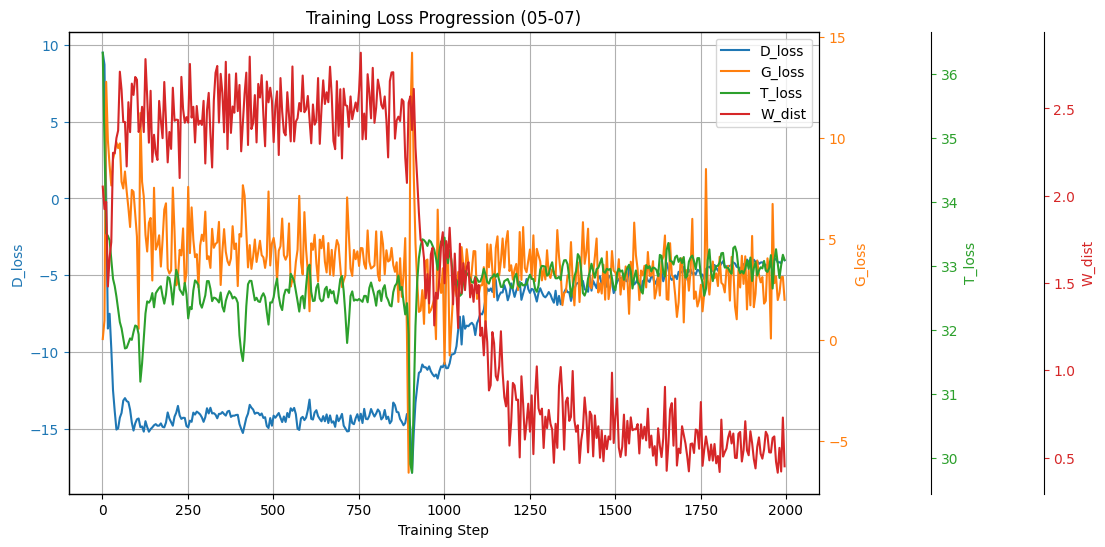

In [6]:
# gan.plot_losses(date_str, save_file_path, logscale={"d": True, "g": True, "t": True, "w": True})
# gan.plot_losses(date_str, save_file_path, logscale={"g": True, "d": True})
gan.plot_losses(date_str, save_file_path)

In [7]:
1

1